# Information Theory Project — LAB 1
## Text Source: Character 


In [ ]:
import math
import random
import collections
import matplotlib.pyplot as plt


with open('Text.txt', 'r', encoding='utf-8') as f:
    raw = f.read()
symbols = list(raw)
print(f'Total symbols: {len(symbols)}') 

Total symbols: 201276



## Task 1 — Single-Symbol Entropy
### Q1a: Estimate the empirical symbol distribution

In [ ]:
# Count how many times each symbol appears
counts = collections.Counter(symbols)
n = len(symbols)

# Empirical probabilities: P(x) = count(x) / total
# probs = {x: c / n for x, c in counts.items()}
probs = {}
for x, c in counts.items():
    probs[x] = c / n

### Q1b: Compute the plug-in entropy estimate

In [ ]:
def entropy(prob_dict):
    # H(X) = -sum P(x) * log2(P(x))
    h = 0.0
    for p in prob_dict.values():
        #else case we don't need to write it 
        if p > 0:
            h -= p * math.log2(p)
    return h

H_plugin = entropy(probs)
alphabet_size = len(probs)
H_max = math.log2(alphabet_size)  # entropy of uniform distribution

print(f'Plug-in entropy estimate: H = {H_plugin:.4f} bits')
print(f'Alphabet size: {alphabet_size}')
print(f'Maximum possible entropy (uniform): {H_max:.4f} bits')

Plug-in entropy estimate: H = 4.4153 bits
Alphabet size: 67
Maximum possible entropy (uniform): 6.0661 bits


### Q1c: Sanity check — apply to a synthetic i.i.d. source with known distribution

In [22]:
# Generate a synthetic source with known probabilities
# Alphabet: {A, B, C}, P(A)=0.5, P(B)=0.3, P(C)=0.2
true_probs = {'A': 0.5, 'B': 0.3, 'C': 0.2}
H_true = entropy(true_probs)
print(f'True entropy of synthetic source: {H_true:.4f} bits')

# Generate 5000 samples
random.seed(42)
syms = list(true_probs.keys())
weights = list(true_probs.values())
synthetic = random.choices(syms, weights=weights, k=5000)

# Plug-in estimate on synthetic data
syn_counts = collections.Counter(synthetic)
syn_probs = {x: c / len(synthetic) for x, c in syn_counts.items()}
H_syn = entropy(syn_probs)
print(f'Plug-in estimate on 5000 samples: {H_syn:.4f} bits')
print(f'Error: {abs(H_syn - H_true):.4f} bits')

True entropy of synthetic source: 1.4855 bits
Plug-in estimate on 5000 samples: 1.4869 bits
Error: 0.0015 bits


### Q1d: How does the entropy estimate evolve with sample size?

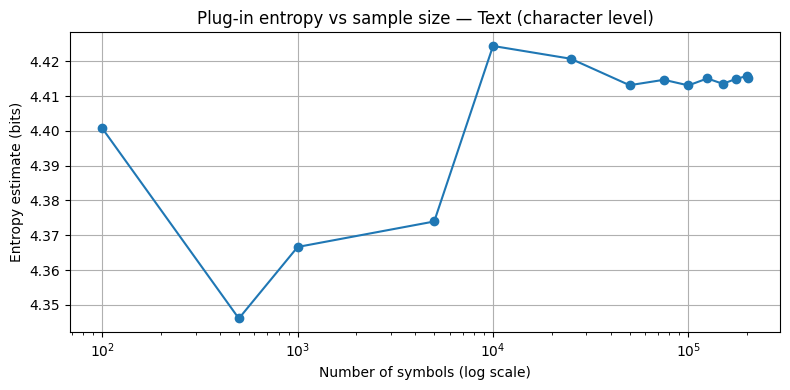

done


In [26]:
# Compute entropy on increasing fractions of the text
sample_sizes = [100, 500, 1000, 5000, 10000, 25000 ,50000, 75000 ,100000,125000,150000,175000,200000,len(symbols)]
sample_sizes = [s for s in sample_sizes if s <= len(symbols)]

H_vs_n = []
for n_s in sample_sizes:
    sub = symbols[:n_s]
    c = collections.Counter(sub)
    p = {x: v / n_s for x, v in c.items()}
    H_vs_n.append(entropy(p))

plt.figure(figsize=(8, 4))
plt.semilogx(sample_sizes, H_vs_n, marker='o')
plt.xlabel('Number of symbols (log scale)')
plt.ylabel('Entropy estimate (bits)')
plt.title('Plug-in entropy vs sample size — Text (character level)')
plt.grid(True)
plt.tight_layout()
plt.savefig('text_entropy_vs_n.png', dpi=100)
plt.show()
print('done')

### Q1e: Bias correction — Miller-Madow correction

In [29]:
# Miller-Madow correction: adds (k-1)/(2n*ln2) to the plug-in estimate
# where k = number of observed symbols, n = sample size

def entropy_miller_madow(symbol_list):
    n = len(symbol_list)
    c = collections.Counter(symbol_list)
    k = len(c)  # number of distinct symbols
    p = {x: v / n for x, v in c.items()}
    h_plugin = entropy(p)
    correction = (k - 1) / (2 * n * math.log(2))
    return h_plugin + correction

# Compare on synthetic data at various sample sizes
print('Synthetic source — plug-in vs Miller-Madow:')
print(f'True entropy: {H_true:.4f} bits')
for n_s in [100, 500, 1000, 5000, 10000, 25000 ,50000, 75000 ,100000,125000,150000,175000,200000,len(symbols)]:
    sub = random.choices(syms, weights=weights, k=n_s)
    c = collections.Counter(sub)
    p = {x: v / n_s for x, v in c.items()}
    h_p = entropy(p)
    h_mm = entropy_miller_madow(sub)
    print(f'  n={n_s:5d}: plug-in={h_p:.4f}, MM={h_mm:.4f}, true={H_true:.4f}')

Synthetic source — plug-in vs Miller-Madow:
True entropy: 1.4855 bits
  n=  100: plug-in=1.5416, MM=1.5560, true=1.4855
  n=  500: plug-in=1.4859, MM=1.4888, true=1.4855
  n= 1000: plug-in=1.4774, MM=1.4789, true=1.4855
  n= 5000: plug-in=1.4890, MM=1.4893, true=1.4855
  n=10000: plug-in=1.4883, MM=1.4885, true=1.4855
  n=25000: plug-in=1.4879, MM=1.4880, true=1.4855
  n=50000: plug-in=1.4852, MM=1.4853, true=1.4855
  n=75000: plug-in=1.4836, MM=1.4836, true=1.4855
  n=100000: plug-in=1.4856, MM=1.4856, true=1.4855
  n=125000: plug-in=1.4868, MM=1.4868, true=1.4855
  n=150000: plug-in=1.4849, MM=1.4849, true=1.4855
  n=175000: plug-in=1.4870, MM=1.4871, true=1.4855
  n=200000: plug-in=1.4855, MM=1.4855, true=1.4855
  n=201276: plug-in=1.4858, MM=1.4858, true=1.4855


---
## Task 2 — Joint and Conditional Entropy
### Q2a: Estimate joint entropy of consecutive symbol pairs H(Xt, Xt-1)

In [30]:
# Build pairs (Xt-1, Xt) from the symbol sequence
pairs = [(symbols[i], symbols[i+1]) for i in range(len(symbols)-1)]
n_pairs = len(pairs)

# Count pair frequencies
pair_counts = collections.Counter(pairs)
pair_probs = {p: c / n_pairs for p, c in pair_counts.items()}

# Joint entropy H(Xt-1, Xt)
H_joint = entropy(pair_probs)
print(f'Joint entropy H(Xt-1, Xt) = {H_joint:.4f} bits')
print(f'Single-symbol entropy H(X) = {H_plugin:.4f} bits')
print(f'If i.i.d.: H(Xt-1, Xt) should equal 2*H(X) = {2*H_plugin:.4f} bits')
print(f'Difference from i.i.d.: {2*H_plugin - H_joint:.4f} bits')

Joint entropy H(Xt-1, Xt) = 7.7403 bits
Single-symbol entropy H(X) = 4.4153 bits
If i.i.d.: H(Xt-1, Xt) should equal 2*H(X) = 8.8305 bits
Difference from i.i.d.: 1.0902 bits


### Q2b: Compute conditional entropy H(Xt | Xt-1)

In [31]:
# H(Xt | Xt-1) = H(Xt-1, Xt) - H(Xt-1)
H_cond = H_joint - H_plugin
print(f'Conditional entropy H(Xt | Xt-1) = {H_cond:.4f} bits')
print(f'Reduction from H(X): {H_plugin - H_cond:.4f} bits')
print()
print('Interpretation:')
print(f'  Knowing the previous symbol reduces uncertainty by {H_plugin - H_cond:.4f} bits.')
if H_cond < H_plugin:
    print('  The source has memory — symbols are NOT independent.')
else:
    print('  No evidence of memory — symbols appear close to independent.')

Conditional entropy H(Xt | Xt-1) = 3.3250 bits
Reduction from H(X): 1.0902 bits

Interpretation:
  Knowing the previous symbol reduces uncertainty by 1.0902 bits.
  The source has memory — symbols are NOT independent.


### Q2c: Finite-sample effects on joint entropy

In [32]:
# Joint entropy estimator is more biased than marginal
# because it has k*k possible pairs instead of k symbols
# Bias ≈ -(km - 1) / (2n * ln2)

k = len(probs)  # alphabet size
n_total = len(symbols)

bias_marginal = (k - 1) / (2 * n_total * math.log(2))
bias_joint = (k * k - 1) / (2 * n_pairs * math.log(2))

print(f'Alphabet size k = {k}')
print(f'Estimated bias of H(X) estimator:         {bias_marginal:.6f} bits')
print(f'Estimated bias of H(Xt-1,Xt) estimator:   {bias_joint:.6f} bits')
print()
print('The joint estimator is more biased because it has more pairs to estimate.')

Alphabet size k = 67
Estimated bias of H(X) estimator:         0.000237 bits
Estimated bias of H(Xt-1,Xt) estimator:   0.016084 bits

The joint estimator is more biased because it has more pairs to estimate.


---
## Task 3 — Entropy Rate Estimation
### Q3a: Block-entropy method — H(X^n) / n for increasing block length n

In [33]:
def block_entropy_rate(seq, block_len):
    # Split sequence into non-overlapping blocks of length block_len
    blocks = []
    for i in range(0, len(seq) - block_len + 1, block_len):
        blocks.append(tuple(seq[i:i+block_len]))
    
    n_blocks = len(blocks)
    if n_blocks < 10:  # not enough blocks to estimate
        return None
    
    c = collections.Counter(blocks)
    p = {b: v / n_blocks for b, v in c.items()}
    H_block = entropy(p)
    return H_block / block_len  # per symbol

block_lengths = [1, 2, 3, 4, 5, 6]
hr_block = []
for bl in block_lengths:
    hr = block_entropy_rate(symbols, bl)
    if hr is not None:
        hr_block.append((bl, hr))
        print(f'Block length {bl}: estimated entropy rate = {hr:.4f} bits/symbol')
    else:
        print(f'Block length {bl}: not enough data')

Block length 1: estimated entropy rate = 4.4153 bits/symbol
Block length 2: estimated entropy rate = 3.8699 bits/symbol
Block length 3: estimated entropy rate = 3.3240 bits/symbol
Block length 4: estimated entropy rate = 2.7936 bits/symbol
Block length 5: estimated entropy rate = 2.3647 bits/symbol
Block length 6: estimated entropy rate = 2.0373 bits/symbol


### Q3b: Conditional-entropy method — H(Xt | Xt-k, ..., Xt-1) for increasing context k

In [36]:
def conditional_entropy_rate(seq, context_len):
    # For each context of length context_len, compute H(next | context)
    # H(Xt | Xt-k:t-1) = H(X^(k+1)) - H(X^k) estimated from data
    
    # Count (context, next_symbol) pairs
    context_next = collections.Counter()
    context_counts = collections.Counter()
    
    for i in range(context_len, len(seq)):
        ctx = tuple(seq[i-context_len:i])
        nxt = seq[i]
        context_next[(ctx, nxt)] += 1
        context_counts[ctx] += 1
    
    # H(Xt | context) = sum over contexts: P(ctx) * H(Xt | ctx)
    total = sum(context_counts.values())
    H_cond = 0.0
    
    for ctx, ctx_count in context_counts.items():
        p_ctx = ctx_count / total
        # Conditional distribution of next symbol given this context
        h_given_ctx = 0.0
        for sym in set(seq):
            c = context_next.get((ctx, sym), 0)
            if c > 0:
                p_sym_given_ctx = c / ctx_count
                h_given_ctx -= p_sym_given_ctx * math.log2(p_sym_given_ctx)
        H_cond += p_ctx * h_given_ctx
    
    return H_cond

context_lengths = [0, 1, 2, 3]
hr_cond = []
for k in context_lengths:
    if k == 0:
        hr = H_plugin
    else:
        hr = conditional_entropy_rate(symbols, k)
    hr_cond.append((k, hr))
    print(f'Context length {k}: H(Xt | past {k}) = {hr:.4f} bits/symbol')

Context length 0: H(Xt | past 0) = 4.4153 bits/symbol
Context length 1: H(Xt | past 1) = 3.3251 bits/symbol
Context length 2: H(Xt | past 2) = 2.2314 bits/symbol
Context length 3: H(Xt | past 3) = 1.2055 bits/symbol


### Q3c: Plot both methods and compare

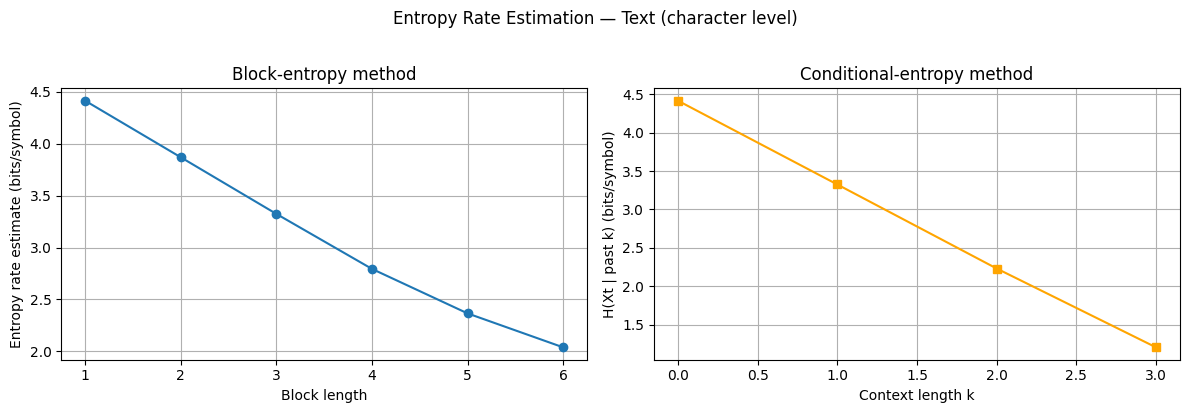

Both methods should converge to the true entropy rate as block/context length increases.
The conditional method is usually more data-efficient.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Block entropy method
bls = [x[0] for x in hr_block]
hrs = [x[1] for x in hr_block]
axes[0].plot(bls, hrs, marker='o')
axes[0].set_xlabel('Block length')
axes[0].set_ylabel('Entropy rate estimate (bits/symbol)')
axes[0].set_title('Block-entropy method')
axes[0].grid(True)

# Conditional entropy method
cls = [x[0] for x in hr_cond]
hrs2 = [x[1] for x in hr_cond]
axes[1].plot(cls, hrs2, marker='s', color='orange')
axes[1].set_xlabel('Context length k')
axes[1].set_ylabel('H(Xt | past k) (bits/symbol)')
axes[1].set_title('Conditional-entropy method')
axes[1].grid(True)

plt.suptitle('Entropy Rate Estimation — Text (character level)', y=1.02)
plt.tight_layout()
plt.savefig('text_entropy_rate.png', dpi=100)
plt.show()

print('Both methods should converge to the true entropy rate as block/context length increases.')
print('The conditional method is usually more data-efficient.')

### Q3d: Bias correction for entropy rate

In [38]:
# Miller-Madow correction for entropy rate at context length 1
# The number of possible (context, symbol) pairs = k^2
# Bias ≈ (k^2 - 1) / (2 * n_pairs * ln2)

k = len(probs)
n_p = len(symbols) - 1  # number of consecutive pairs

H_cond_raw = conditional_entropy_rate(symbols, 1)
correction = (k * k - 1) / (2 * n_p * math.log(2))
H_cond_corrected = H_cond_raw + correction

print(f'H(Xt | Xt-1) plug-in:   {H_cond_raw:.4f} bits')
print(f'Miller-Madow correction: +{correction:.6f} bits')
print(f'Corrected estimate:      {H_cond_corrected:.4f} bits')
print()
print('With large n, the correction is very small.')

H(Xt | Xt-1) plug-in:   3.3251 bits
Miller-Madow correction: +0.016084 bits
Corrected estimate:      3.3411 bits

With large n, the correction is very small.
